In [1]:
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import polars as pl
import alphalens as al
import matplotlib.pyplot as plt
from datetime import datetime

# 配置文件
try:
    import config_local as config
except ImportError:
    import config

# 导入数据接口sdk
import zenidatasdk as zd
client = zd.Client(
    base_url=config.ZENI_URL,
    username=config.ZENI_USERNAME,
    password=config.ZENI_PASSWORD,
)

# 忽视警告信息
warnings.filterwarnings(action = 'ignore')

In [2]:
# 历史回测区间
init_date = '2025-11-01'
start_date = '2025-11-15'
end_date = str(datetime.today().date())
index_symbol = rf"000852.XSHG"

# rf"000300.XSHG",  # 沪深300
# rf"000905.XSHG",  # 中证500
# rf"000852.XSHG",  # 中证1000
# rf"000016.XSHG",  # 上证50
# rf"399006.XSHE",  # 创业板

In [3]:
# 获取指数成分股数据据
index_weights_df = client.get_index_constituents_df(
    index_symbol=index_symbol,
    start_date=start_date,
    end_date=end_date
)
index_weights_df = index_weights_df.rename(columns={"date": "datetime"})
symbols = index_weights_df["symbol"].unique().tolist()
index_weights_df

,datetime,index_symbol,update_date,symbol,weight,display_name
0,2025-11-17,000852.XSHG,2025-10-31,000012.XSHE,0.069,南玻A
1,2025-11-17,000852.XSHG,2025-10-31,000019.XSHE,0.028,深粮控股
2,2025-11-17,000852.XSHG,2025-10-31,000025.XSHE,0.044,特力A
3,2025-11-17,000852.XSHG,2025-10-31,000028.XSHE,0.061,国药一致
4,2025-11-17,000852.XSHG,2025-10-31,000029.XSHE,0.094,深深房A
...,...,...,...,...,...,...
105995,2026-04-24,000852.XSHG,2026-03-31,688776.XSHG,0.055,国光电气
105996,2026-04-24,000852.XSHG,2026-03-31,688779.XSHG,0.143,五矿新能
105997,2026-04-24,000852.XSHG,2026-03-31,688789.XSHG,0.084,宏华数科
105998,2026-04-24,000852.XSHG,2026-03-31,688798.XSHG,0.073,艾为电子


In [4]:
# ================ 定义本地分钟数据路径 ================
tmp_Dataset_path = rf"D:\tmp_Dataset"
minute_bar_Dataset_path = os.path.join(tmp_Dataset_path, "minute_bar")  # 分钟数据本地路径
os.makedirs(minute_bar_Dataset_path, exist_ok=True)

index_weights_path = os.path.join(minute_bar_Dataset_path, index_symbol)  # 指数成分股
os.makedirs(index_weights_path, exist_ok=True)


# ================ 按月获取分钟数据 ================
def generate_monthly_ranges_dict(start_date, end_date):
    """生成按月切割的日期区间字典，格式为 {YYMM: (月初, 月末)}"""
    start = datetime.strptime(start_date, '%Y-%m-%d').date()
    end = datetime.strptime(end_date, '%Y-%m-%d').date()

    date_dict = {}
    current = start

    import calendar
    while True:
        month_start = current.replace(day=1)
        _, last_day = calendar.monthrange(current.year, current.month)
        month_end = current.replace(day=last_day)

        if month_end > end:  # 不足一个月舍弃
            break

        # 键格式：YYMM（如 2603 表示 2026年03月）
        key = f"{str(current.year)[-2:]}{current.month:02d}"
        date_dict[key] = (month_start.strftime('%Y-%m-%d'), month_end.strftime('%Y-%m-%d'))

        # 移到下个月
        if current.month == 12:
            current = current.replace(year=current.year + 1, month=1, day=1)
        else:
            current = current.replace(month=current.month + 1, day=1)

    return date_dict

date_tuple_list = generate_monthly_ranges_dict(init_date, end_date)
date_tuple_list

{'2511': ('2025-11-01', '2025-11-30'),
 '2512': ('2025-12-01', '2025-12-31'),
 '2601': ('2026-01-01', '2026-01-31'),
 '2602': ('2026-02-01', '2026-02-28'),
 '2603': ('2026-03-01', '2026-03-31')}

In [5]:
def tmp_filter(dataframe):
    # 1. 临时转换为 datetime 用于过滤
    # 2. 过滤后删除临时列，保留原始字符串
    return None
tmp_filter = None


from tqdm import tqdm
big_minute_bar_dict = {}
for month, start_end_tuple in tqdm(
    date_tuple_list.items(), desc = "获取每月分钟数据"
):

    minute_bar_monthly_path = os.path.join(index_weights_path, rf"{month}.parquet")
    if os.path.exists(minute_bar_monthly_path):
        bars_1m_df_tmp = pd.read_parquet(minute_bar_monthly_path)
    else:
        bars_1m_df_tmp = client.get_kline_df(
            symbol = symbols,
            start_date = start_end_tuple[0],
            end_date = start_end_tuple[1],
            frequency = "1m",
            adjust_type = "post",
            market = "cn_stock",
        )
        bars_1m_df_tmp.to_parquet(minute_bar_monthly_path, engine = 'pyarrow',compression = 'snappy')

    # 删除部分数据，减少内存负担 tmp_filter
    if tmp_filter:
        big_minute_bar_dict[month] = tmp_filter(bars_1m_df_tmp)
    else:
        big_minute_bar_dict[month] = bars_1m_df_tmp
    import gc; gc.collect()


# 分钟数据长表格 bars_1m_df
bars_1m_df = pd.concat(list(big_minute_bar_dict.values()))
bars_1m_df.head()

获取每月分钟数据: 100%|██████████| 5/5 [00:02<00:00,  1.80it/s]


,open,high,low,close,volume,symbol,amount,datetime
0,652.72,652.72,641.36,641.36,46146.83,000006.XSHE,29887897.0,2025-11-03 09:31:00
1,641.36,641.88,635.17,635.17,35893.05,000006.XSHE,22902399.0,2025-11-03 09:32:00
2,632.58,635.17,619.67,622.77,54638.38,000006.XSHE,34146136.0,2025-11-03 09:33:00
3,621.74,623.81,615.03,622.77,61855.72,000006.XSHE,38316132.0,2025-11-03 09:34:00
4,622.77,630.00,622.77,623.29,45381.91,000006.XSHE,28385346.0,2025-11-03 09:35:00


In [6]:
import gc; gc.collect()

18

In [7]:
# 获取日频估值数据
fundamental_1d_df = client.get_valuation_df(
    symbols=symbols,
    start_date=start_date,
    end_date=end_date,
    fields="datetime,symbol,market_cap,circulating_market_cap,turnover_ratio,pe_ratio,pb_ratio,dividend_ratio"
)

# 构建市值数据
mkt_cap_name = "market_cap"
market_cap_df = fundamental_1d_df.set_index(["datetime", "symbol"])[[mkt_cap_name]]

# 负数和无穷值 & 对数处理
market_cap_df[mkt_cap_name] = np.where((market_cap_df[mkt_cap_name] <= 0) | (~np.isfinite(market_cap_df[mkt_cap_name])),
                                       0, market_cap_df[mkt_cap_name])
market_cap_df[f"{mkt_cap_name}_log"] = np.log1p(market_cap_df[mkt_cap_name])
market_cap = market_cap_df[f"{mkt_cap_name}_log"]
market_cap.head()

datetime    symbol     
2025-11-17  000012.XSHE    5.028424
            000019.XSHE    4.446943
            000025.XSHE    4.429536
            000028.XSHE    4.971230
            000029.XSHE    5.544936
Name: market_cap_log, dtype: float64

In [8]:
# # 获取行业数据
# industry_constituents_df = client.get_industry_constituents_composite_df(
#     symbols = symbols,
#     category = "sw_l1",
#     start_date = start_date,
#     end_date = end_date
# )
#
# # 构建双重索引的行业数据
# industries = industry_constituents_df.set_index(["datetime", "symbol"])["industry_name"]
# industries

In [8]:
# 转化并提取日级数据
prices_df = bars_1m_df[bars_1m_df['datetime'] >= start_date].copy()
prices_df = bars_1m_df.rename(columns={'datetime': 'datetime_min'})
prices_df['datetime'] = prices_df['datetime_min'].dt.normalize()

# 把日级数据透视为符合 alphalens 格式的开盘价表格
# 策略回测以每天收盘完，因子完成计算后，次日以开盘价买入为准
prices_df = prices_df.groupby(['datetime', "symbol"]).agg(open=('open', 'first')).reset_index()
prices = prices_df.pivot(index='datetime', columns='symbol', values='open')
prices.head().T.head().T

symbol,000006.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000016.XSHE
datetime,,,,,
2025-11-03,652.72,50.78,50.22,173.89,132.01
2025-11-04,637.75,53.57,48.93,174.25,133.47
2025-11-05,599.53,51.58,47.46,174.25,132.49
2025-11-06,622.77,52.51,48.15,176.81,134.20
2025-11-07,621.22,51.31,47.04,177.18,133.22


In [9]:
def f_0322(bars: pd.DataFrame, market_cap: pd.DataFrame, f_name: str = 'PV_corr', roll_days: int = 20) -> pd.DataFrame:
    """
    factor_intro: 利用成交量的信息，修正传统反转因子对股票价格涨跌的判断；
                  通过度量过去一段时间的价量相关性，捕捉价格涨跌是否有量的确认。
    category: 高频因子
    category_intro: 量价相关性类
    subcategory:
    subcategory_intro:
    min_period: 20d
    source: 陈子信, 2020, 再论价量相关性, 意想不到的选股因子, 东吴证券
    author: 因子团队

    说明：每月月底，回溯每只股票过去 roll_days 个交易日的分钟频价量信息，
          每日计算分钟收盘价与分钟成交量的相关系数 PV_corr，
          再取过去 roll_days 日 PV_corr 的均值，最后做横截面市值中性化处理，
          得到价量相关性平均数因子 PV_corr_avg。
          因子方向需根据实证结果判断（通常反转效应下为负向）。

    Parameters
    ----------
    bars: pd.DataFrame
        分钟频 bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume']
    market_cap: pd.DataFrame
        市值数据，用于横截面中性化
        index: [symbol, datetime]
        columns: 至少包含 ['market_cap_log']（或代码中实际使用的市值列）
    f_name: str
        因子名称，默认为 'PV_corr_avg'
    roll_days: int
        回溯交易日数，默认为 20。即取过去 roll_days 日的价量相关系数均值。

    Returns
    -------
    factors: pd.DataFrame
        日频 factors
        ['datetime', 'symbol', 'factor_name', 'factor_value']
    """


    bars_min = bars

    # 分离时间轴 分钟与天
    bars_min = bars_min.rename(columns = {'datetime': 'datetime_min'})
    bars_min = bars_min.sort_values(['symbol', 'datetime_min'], ascending = True)
    bars_min['datetime'] = bars_min['datetime_min'].dt.normalize()

    # ================ 日内分钟相关系数计算 =====================

    # 皮尔逊相关系数公式：r = Cov(X, Y) / (σ_X · σ_Y)
    # 为了避免逐日循环计算均值，这里使用“求和形式”的代数等价变形
    # 需要预先计算以下四项的日度求和：
    #   Σ(X·Y), Σ(X²), Σ(Y²), ΣX, ΣY, n
    bars_min['close_mul_volume'] = bars_min['close'] * bars_min['volume']
    bars_min['close_pwr2'] = bars_min['close'] ** 2
    bars_min['volume_pwr2'] = bars_min['volume'] ** 2

    # 按 (symbol, 交易日) 分组，汇总当日所有分钟 K 线的统计量
    bars_daily = (
        bars_min
        .groupby(by=['symbol', 'datetime'])
        .agg(
            N_of_Klines=('datetime_min', 'count'),            # 当日 K 线数
            Sum_close_mul_volume=('close_mul_volume', 'sum'), # Σ(X·Y)
            Sum_close_pwr2=('close_pwr2', 'sum'),             # Σ(X²)
            Sum_volume_pwr2=('volume_pwr2', 'sum'),           # Σ(Y²)
            Sum_close=('close', 'sum'),                       # ΣX
            Sum_volume=('volume', 'sum'),                     # ΣY
        )
    )


    # 【相关系数原定义】
    #   r = Cov(X, Y) / (σ_X · σ_Y)
    # 其中：
    #   Cov(X, Y) = Σ[(X_i - X̄)(Y_i - Ȳ)] / n          （总体协方差，除以 n）
    #   σ_X = √[Σ(X_i - X̄)² / n]
    #   σ_Y = √[Σ(Y_i - Ȳ)² / n]
    # 【等价的变形】
    # 直接展开协方差分子：
    #   Σ[(X_i - X̄)(Y_i - Ȳ)] = Σ(XY) - n·X̄·Ȳ
    #                         = Σ(XY) - (ΣX)(ΣY)/n
    #   n·Σ[(X_i - X̄)(Y_i - Ȳ)] = n·Σ(XY) - (ΣX)(ΣY)      ← 代码中的 Numerator
    # 同理，方差项：
    #   Σ[(X_i - X̄)²] = Σ(X²) - (ΣX)²/n
    #   n·Σ[(X_i - X̄)²] = n·Σ(X²) - (ΣX)²                ← 分母中第一个括号
    #   n·Σ[(Y_i - Ȳ)²] = n·Σ(Y²) - (ΣY)²                ← 分母中第二个括号
    # 【最终代码公式】
    #   r = [n·Σ(XY) - ΣX·ΣY] / √{[n·Σ(X²) - (ΣX)²] · [n·Σ(Y²) - (ΣY)²]}

    Numerator = (  # 协方差部分的分子  n·Σ(XY) - ΣX·ΣY
        bars_daily['N_of_Klines'] * bars_daily['Sum_close_mul_volume'] -
        bars_daily['Sum_close'] * bars_daily['Sum_volume']
    )
    Denominator = np.sqrt(  # 分母标准差部分的乘积  √{[n·Σ(X²)-(ΣX)²] · [n·Σ(Y²)-(ΣY)²]}
        (bars_daily['N_of_Klines'] * bars_daily['Sum_close_pwr2'] - bars_daily['Sum_close'] ** 2) *
        (bars_daily['N_of_Klines'] * bars_daily['Sum_volume_pwr2'] - bars_daily['Sum_volume'] ** 2)
    )
    bars_daily = pd.DataFrame(  # 计算每日相关系数
        (Numerator / Denominator).rename('PV_corr')
    )

    # ================ 滚动统计量 & 合并市值列 =====================

    # 分组滚动后转化为 dataframe
    PV_corr_mean = (
        bars_daily
        .groupby('symbol')['PV_corr']
        .rolling(window = roll_days)
        .mean()
    )
    PV_corr_mean = pd.DataFrame(
        PV_corr_mean
        .reset_index(level = 0, drop = True)
        .rename('PV_corr_mean')
    )

    # 合并市值列
    bars_daily = pd.merge(
        left = PV_corr_mean,
        right = market_cap,
        left_index = True,
        right_index = True,
        how = 'outer'
    )

    # ================ 按日分组，在组内中性化处理 =====================
    def _neutralize(group: pd.DataFrame) -> pd.Series:
        """
        group: 某一天（截面）的所有票
        返回: PV_corr 对 market_cap_log 回归的残差
        """

        # 1. 筛选有效行
        mask = ~ group[['PV_corr_mean', 'market_cap_log']].isna().any(axis = 1)
        n = int(mask.sum())

        if n < 3: return pd.Series(np.nan, index = group.index, name = 'PV_corr_neutral')

        x = group.loc[mask, 'market_cap_log'].values
        y = group.loc[mask, 'PV_corr_mean'].values

        # 2. OLS 解析解
        X = np.vstack([
            np.ones(n),   # 截距项载荷
            x,            # 市值变量载荷
        ]).T
        coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
        alpha, beta = coeffs[0], coeffs[1]

        # 3. 残差
        resid = y - (alpha + beta * x)

        result = pd.Series(np.nan, index = group.index, name = 'PV_corr_neutral')
        result.loc[group.loc[mask].index] = resid
        return result

    bars_daily['factor_value'] = (
        bars_daily
        .groupby('datetime')
        .apply(_neutralize)
        .reset_index(level = 0, drop = True)
    )

    # ================ 转化为智盈量化格式 =====================
    bars_daily = bars_daily.reset_index()
    bars_daily['factor_name'] = f_name

    return bars_daily[['datetime', 'symbol', 'factor_name', 'factor_value']]

In [10]:
# 计算因子数据
factors_df = f_0322(
    bars = bars_1m_df,
    market_cap = market_cap,
    f_name = 'PV_corr',
    roll_days = 20
)
factors_df

,datetime,symbol,factor_name,factor_value
0,2025-11-03,000006.XSHE,PV_corr,NaN
1,2025-11-04,000006.XSHE,PV_corr,NaN
2,2025-11-05,000006.XSHE,PV_corr,NaN
3,2025-11-06,000006.XSHE,PV_corr,NaN
4,2025-11-07,000006.XSHE,PV_corr,NaN
...,...,...,...,...
243641,2026-04-20,688800.XSHG,PV_corr,NaN
243642,2026-04-21,688800.XSHG,PV_corr,NaN
243643,2026-04-22,688800.XSHG,PV_corr,NaN
243644,2026-04-23,688800.XSHG,PV_corr,NaN


In [14]:
factors_df[factors_df['symbol'] == '000006.XSHE']

,datetime,symbol,factor_name,factor_value
0,2025-11-03,000006.XSHE,PV_corr,NaN
1,2025-11-04,000006.XSHE,PV_corr,NaN
2,2025-11-05,000006.XSHE,PV_corr,NaN
3,2025-11-06,000006.XSHE,PV_corr,NaN
4,2025-11-07,000006.XSHE,PV_corr,NaN
...,...,...,...,...
94,2026-03-25,000006.XSHE,PV_corr,NaN
95,2026-03-26,000006.XSHE,PV_corr,NaN
96,2026-03-27,000006.XSHE,PV_corr,NaN
97,2026-03-30,000006.XSHE,PV_corr,NaN


In [11]:
# 因子值 shift 1 转换成实际使用时间(T+1)
factors_df['factor_value'] = factors_df.groupby(['symbol'])['factor_value'].transform(lambda x: x.shift(1))

# 与指数的交易日历、历史成分股数据对齐
factor_df= pd.merge(left = index_weights_df[['datetime', 'symbol']], right = factors_df, how = 'left', on = ['datetime', 'symbol'])

# 转换成[datetime, symbol]双重索引的factors
factors = factor_df.pivot_table(index = ['datetime', 'symbol'], columns = 'factor_name', values = 'factor_value')
factors.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 78616 entries, (Timestamp('2025-12-01 00:00:00'), '000012.XSHE') to (Timestamp('2026-04-01 00:00:00'), '688800.XSHG')
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   PV_corr  78616 non-null  float64
dtypes: float64(1)
memory usage: 853.9+ KB


In [12]:
# 调用alphalens进行数据清洗
factor_data = al.utils.get_clean_factor_and_forward_returns(
    factor=factors,
    prices=prices,
    periods=(1, 5, 20),
    bins=None,
    quantiles=7,
    groupby=None,
    groupby_labels=None,
    binning_by_group=False,
    filter_zscore=20,
    max_loss=0.75,
    zero_aware=False,
    cumulative_returns=True
)
factor_data

Dropped 26.3% entries from factor data: 26.3% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 75.0%, not exceeded: OK!


1D        5D       20D    factor  \
date       asset                                                 
2025-12-01 000012.XSHE  0.010727  0.017116 -0.036401 -0.041014   
           000019.XSHE -0.009742 -0.008443 -0.009742  0.023049   
           000025.XSHE -0.024816 -0.069592 -0.114548  0.003856   
           000028.XSHE  0.004031  0.010819 -0.004808 -0.045017   
           000029.XSHE -0.008895 -0.052001 -0.056791  0.055255   
...                          ...       ...       ...       ...   
2026-03-03 688776.XSHG -0.060077  0.014271 -0.229590 -0.006991   
           688779.XSHG -0.080000 -0.026667 -0.086667 -0.048138   
           688789.XSHG -0.022491 -0.091102 -0.206820 -0.021369   
           688798.XSHG -0.086003 -0.065981 -0.151620  0.001223   
           688800.XSHG -0.076401 -0.090248 -0.161476  0.024155   

                        factor_quantile  
date       asset                         
2025-12-01 000012.XSHE                2  
           000019.XSHE                5  
           000025.XSHE                4  
           000028.XSHE                2  
           000029.XSHE                6  
...                                 ...  
2026-03-03 688776.XSHG                4  
           688779.XSHG                2  
           688789.XSHG                3  
           688798.XSHG                4  
           688800.XSHG                5  

[57923 rows x 5 columns]

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.392450,-0.056120,-0.094035,0.031350,8300,14.329368
2,-0.071991,-0.030549,-0.048429,0.008695,8260,14.260311
3,-0.040633,-0.007725,-0.023551,0.006996,8268,14.274123
4,-0.017862,0.017769,-0.001119,0.007023,8269,14.275849
5,0.005436,0.042242,0.022080,0.007533,8266,14.270670
6,0.027045,0.073151,0.048888,0.009660,8262,14.263764
7,0.057766,0.226202,0.096987,0.026774,8298,14.325915


Returns Analysis


,1D,5D,20D
Ann. alpha,-0.080,-0.040,-0.055
beta,0.159,0.232,0.322
Mean Period Wise Return Top Quantile (bps),-3.208,2.906,4.717
Mean Period Wise Return Bottom Quantile (bps),0.967,0.310,-1.391
Mean Period Wise Spread (bps),-4.176,2.550,6.061


<Figure size 640x480 with 0 Axes>

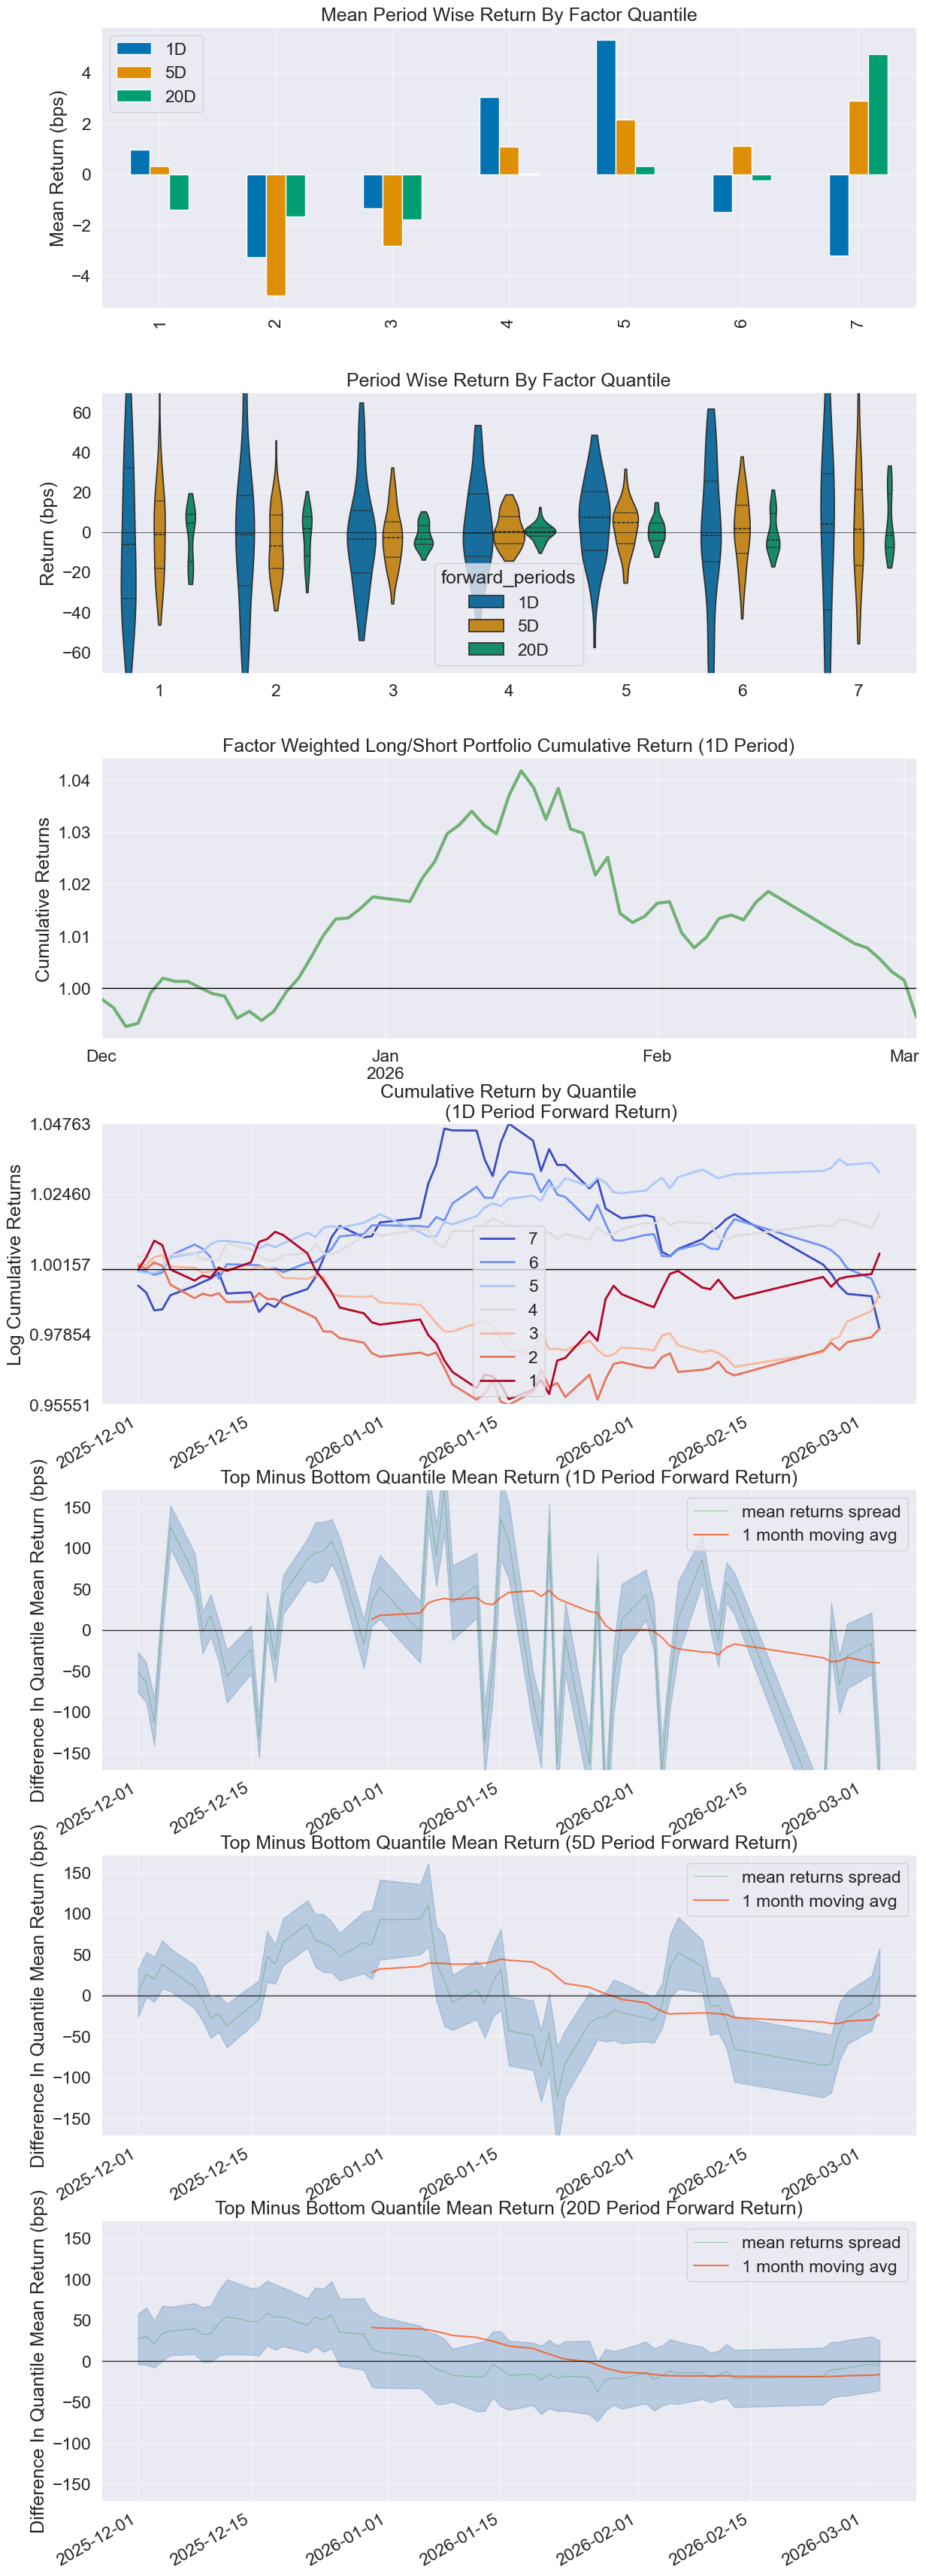

Information Analysis


,1D,5D,20D
IC Mean,-0.019,-0.002,-0.010
IC Std.,0.136,0.154,0.186
Risk-Adjusted IC,-0.142,-0.015,-0.054
t-stat(IC),-1.091,-0.114,-0.413
p-value(IC),0.280,0.909,0.681
IC Skew,-0.265,0.183,0.538
IC Kurtosis,-0.973,-1.104,-1.306


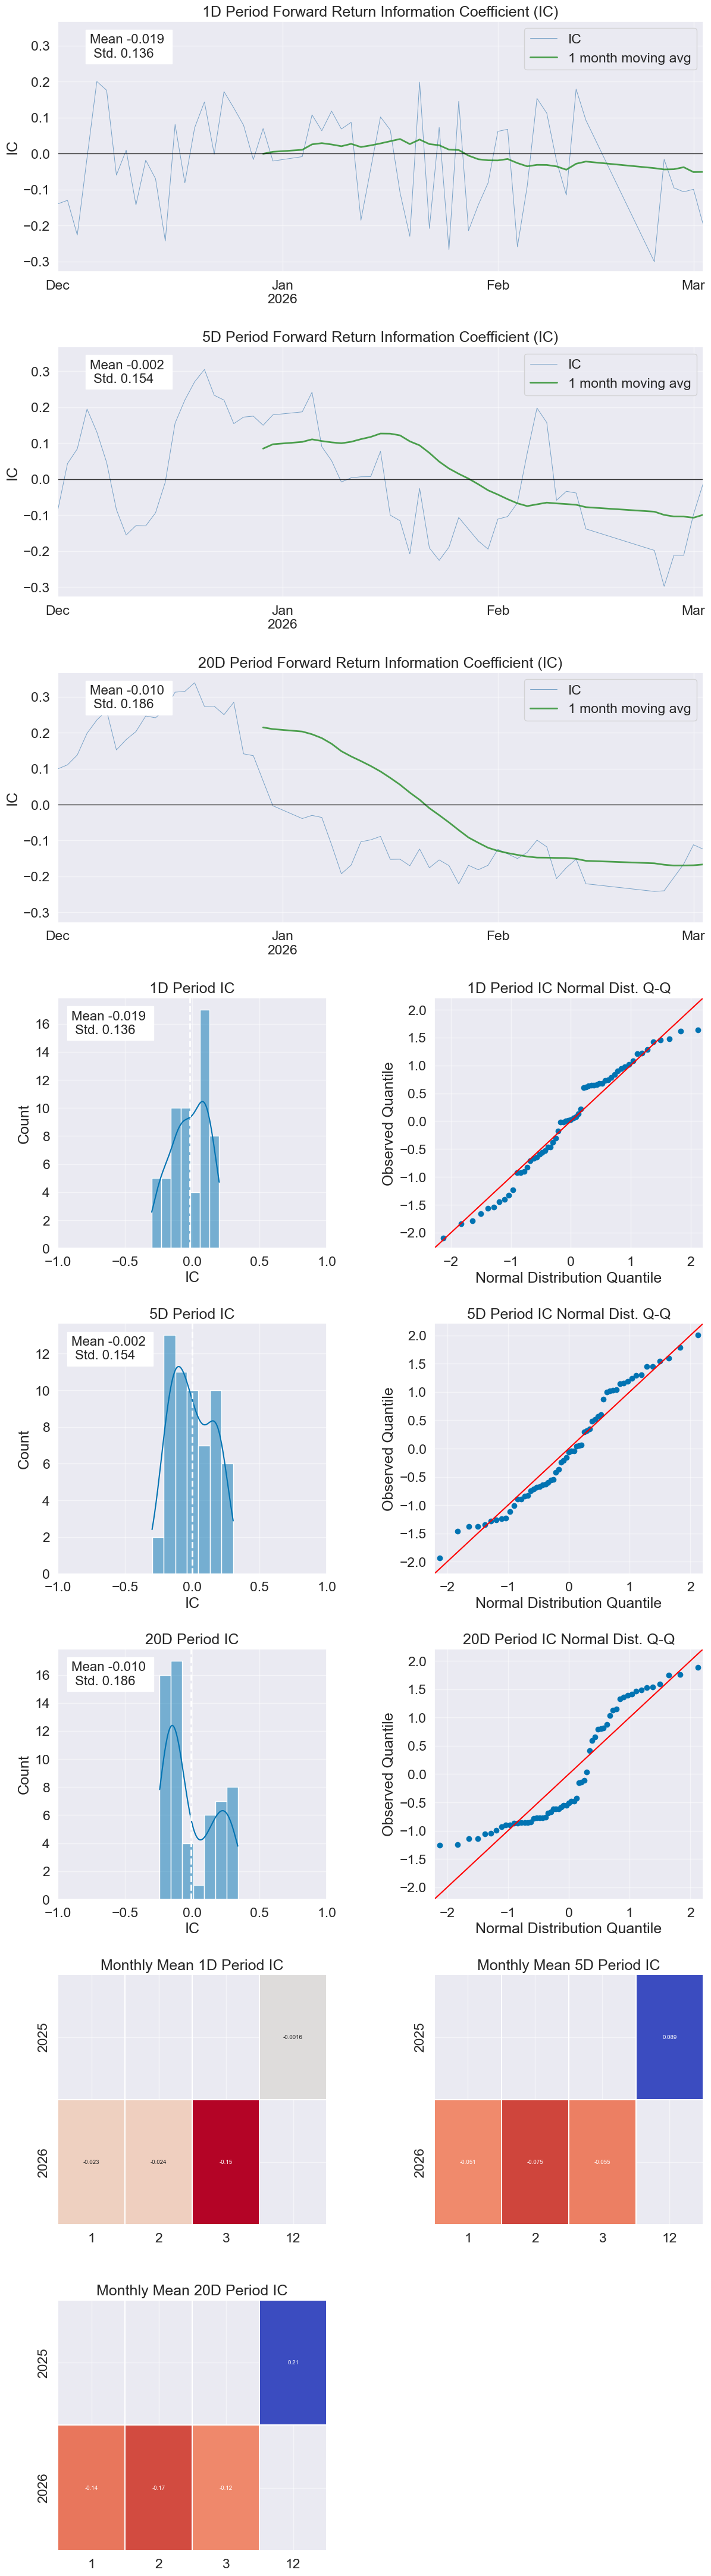

Turnover Analysis


,1D,5D,20D
Quantile 1 Mean Turnover,0.159,0.376,0.777
Quantile 2 Mean Turnover,0.381,0.665,0.823
Quantile 3 Mean Turnover,0.459,0.719,0.853
Quantile 4 Mean Turnover,0.481,0.736,0.861
Quantile 5 Mean Turnover,0.465,0.727,0.855
Quantile 6 Mean Turnover,0.396,0.667,0.842
Quantile 7 Mean Turnover,0.167,0.384,0.811


,1D,5D,20D
Mean Factor Rank Autocorrelation,0.966,0.818,0.236


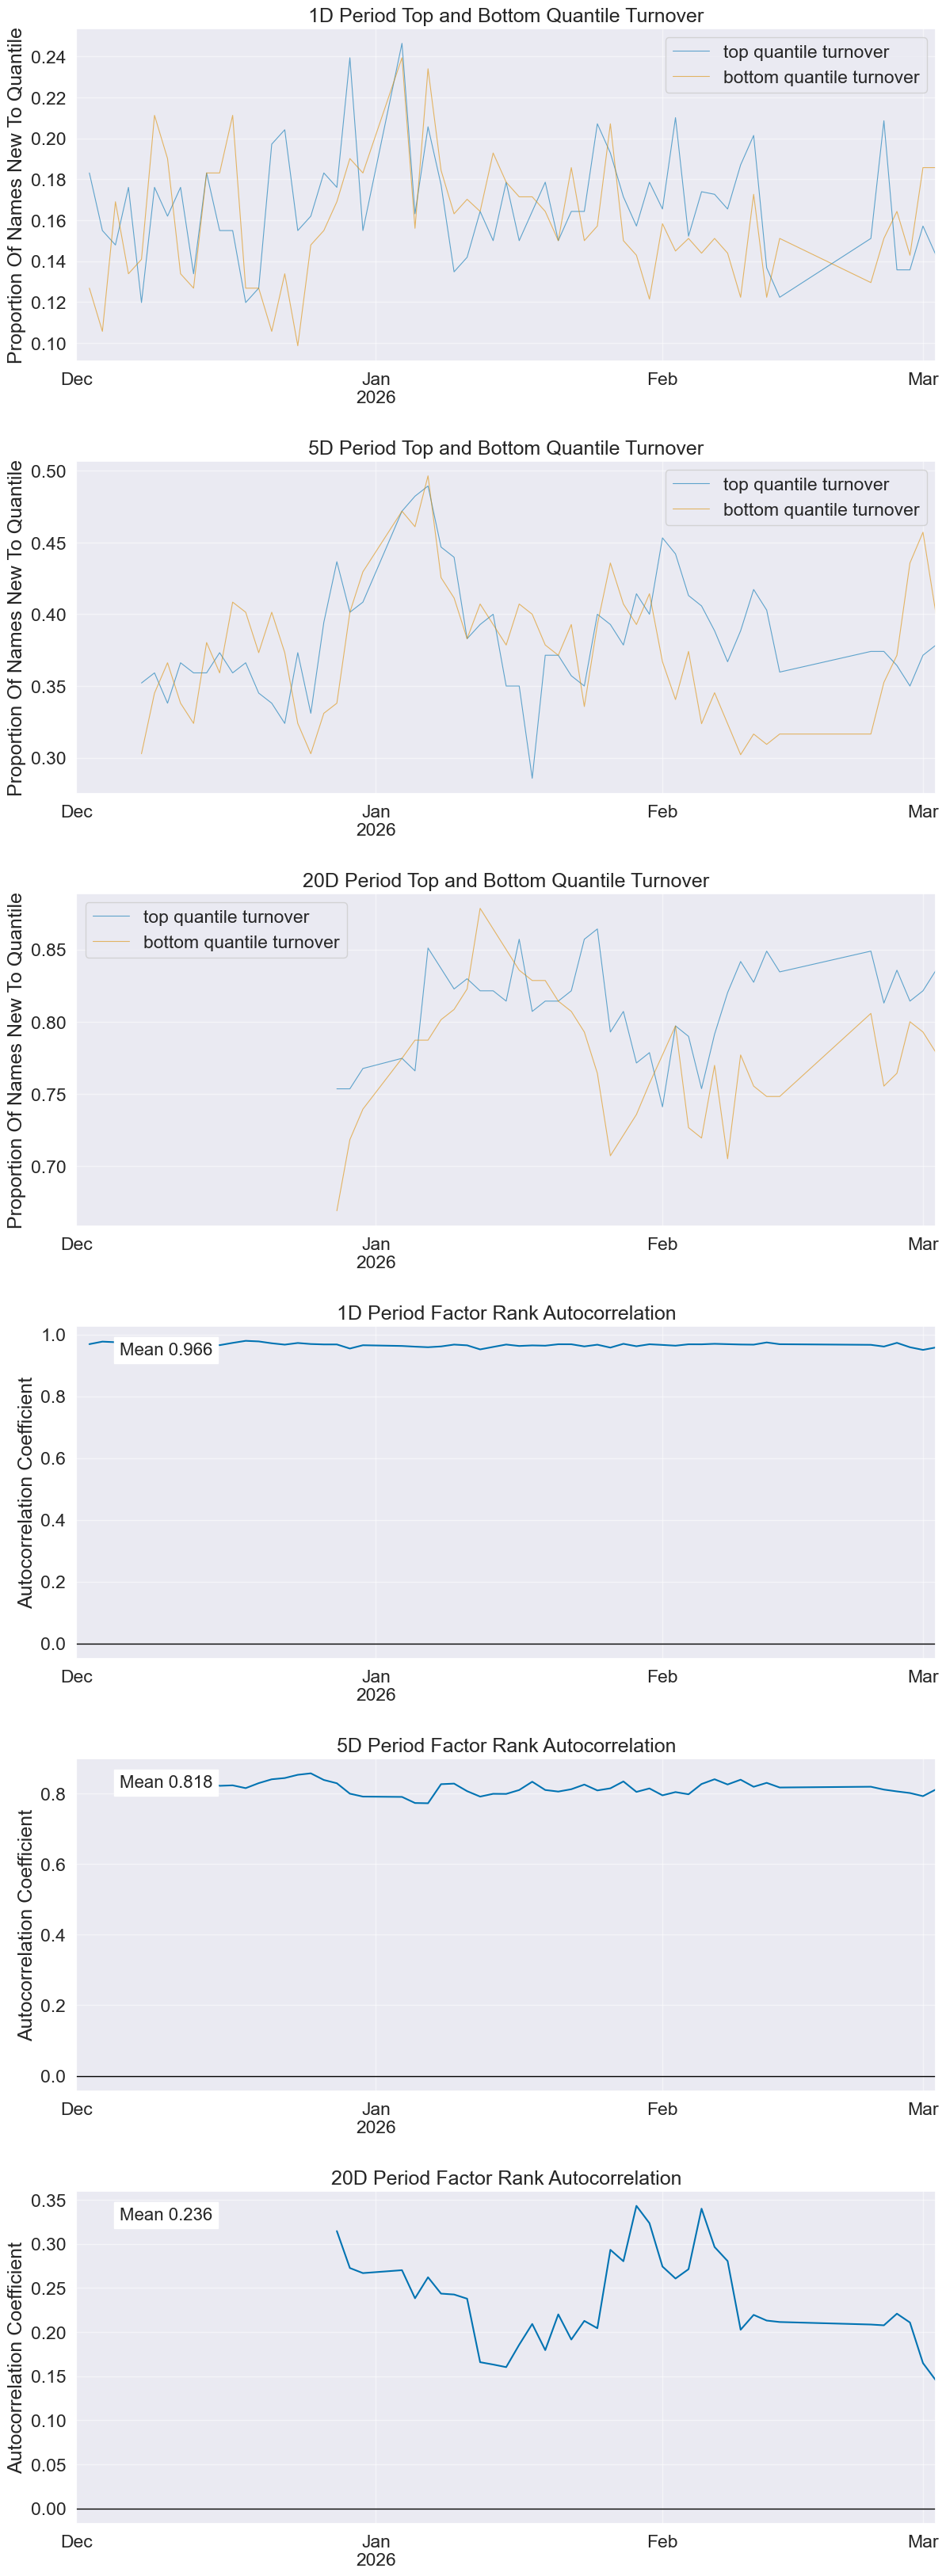

In [13]:
# 调用alphalens进行因子评估
al.tears.create_full_tear_sheet(
    factor_data=factor_data,
    long_short=True,
    group_neutral=False,
    by_group=False
)

In [76]:
import gc; gc.collect()

15